In [8]:
import csv
import os
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
HAS_MPL = True

In [10]:
def _read_training_csv(path: str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(path)
    if "episode" not in df.columns or "return" not in df.columns:
        raise ValueError("CSV must contain 'episode' and 'return' columns")
    episodes = df["episode"].to_numpy(dtype=int)
    returns = df["return"].to_numpy(dtype=float)
    return episodes, returns

In [11]:
def _moving_average(values: np.ndarray, window: int) -> np.ndarray:
    if window <= 1 or len(values) == 0:
        return values.copy()
    window = min(window, len(values))
    kernel = np.ones(window, dtype=np.float64) / float(window)
    return np.convolve(values, kernel, mode="valid")

ValueError: x and y must have same first dimension, but have shapes (0,) and (1,)

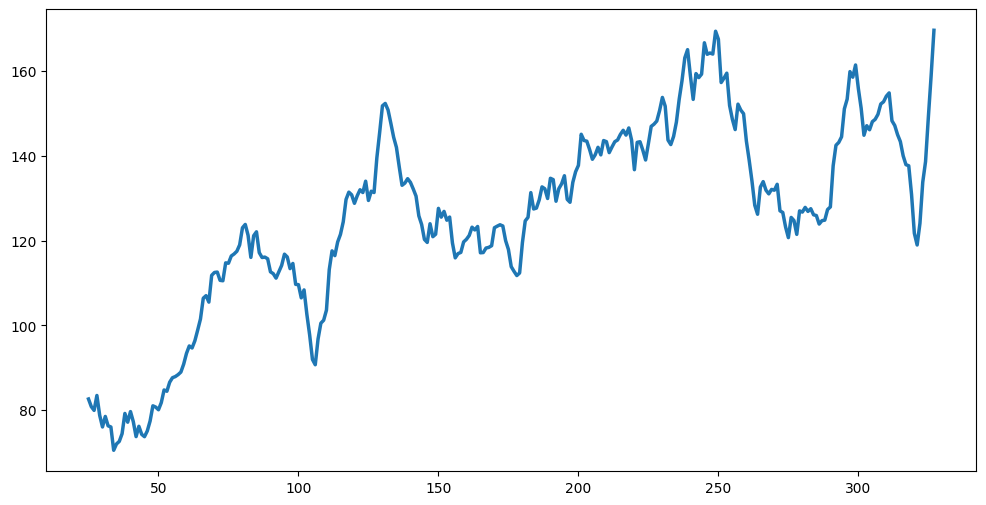

In [ ]:
CSV_FILES = [
    # "../logs/training_logs/training_log_6.csv",
    # "../logs/training_logs/training_log_7.csv",
    "../logs/training_logs/training_log_8.csv",
]
EVAL_FILES = [
    # "../logs/eval_logs/eval_log_1.csv",
    # "../logs/eval_logs/eval_log_2.csv",
    "../logs/eval_logs/eval_log_5.csv",
]
TRAINING_LOG = "../logs/training_logs/training_log_8.csv"
WINDOW = 25
OUT_DIR = "logs/analysis"

logs_dir = os.path.join("logs", "training_logs")
paths = CSV_FILES 
train_path = TRAINING_LOG

episodes, returns = _read_training_csv(train_path)
if len(episodes) == 0:
    raise RuntimeError(f"No rows found in {train_path}")

moving_avg = _moving_average(returns, WINDOW)
best_so_far = np.maximum.accumulate(returns)

if not HAS_MPL:
    print("matplotlib not installed; install with: pip install matplotlib")
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    for path in paths:
        multi_episodes, multi_returns = _read_training_csv(path)
        if len(multi_episodes) == 0:
            raise RuntimeError(f"No rows found in {path}")
        multi_moving_avg = _moving_average(multi_returns, WINDOW)
        if len(multi_moving_avg) == 0:
            continue
        multi_ma_x = multi_episodes[WINDOW - 1 :]
        label = os.path.basename(path)
        ax.plot(multi_ma_x, multi_moving_avg, linewidth=2.5, label=label)

    for eval_path in EVAL_FILES:
        eval_episodes, eval_returns = _read_training_csv(eval_path)
        if len(eval_episodes) == 0:
            raise RuntimeError(f"No rows found in {eval_path}")
        eval_moving_avg = _moving_average(eval_returns, WINDOW)
        if len(eval_moving_avg) == 0:
            continue
        eval_ma_x = eval_episodes[WINDOW - 1 :]
        eval_label = f"eval {os.path.basename(eval_path)}"
        ax.plot(eval_ma_x, eval_moving_avg, linewidth=2.5, linestyle="--", label=eval_label)

    ax.set_title("Training Return Moving Averages")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(episodes, returns, color="#9aa0a6", linewidth=1, alpha=0.6, label="return")
    ax.plot(episodes, best_so_far, color="#1a73e8", linewidth=2, label="best so far")

    if len(moving_avg) > 0:
        ma_x = episodes[WINDOW - 1 :]
        ax.plot(ma_x, moving_avg, color="#34a853", linewidth=2.5, label=f"moving avg ({WINDOW})")

    ax.set_title("Training Return Trend")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    plt.show()